In [1]:
import numpy as np
import readgadget
import bigfile
import MAS_library as MASL
import Pk_library as PKL
import matplotlib.pyplot as plt
from pylab import *
import dddf

def drawfigs(best_fit_psi_div):
    plt.cla()

    hb = plt.hexbin(
        -best_fit_psi_div.reshape(N_p**3),
        -target_psi_div.reshape(N_p**3),
        gridsize=500,
        cmap="vir" \
        "idis",
        mincnt=0,
        bins="log",
    )
    plt.axline((0, 0), (1, 1), color="red", linestyle="--", linewidth=1)
    plt.colorbar(hb, label="Count")
    plt.title(r"$(-\nabla\cdot\psi)_{N-body}-(-\nabla\cdot\psi)_{best-fit}$")
    plt.xlabel(r"$(-\nabla\cdot\psi)_{best-fit}$")
    plt.ylabel(r"$(-\nabla\cdot\psi)_{N-body}$")
    plt.xlim((-5, 7))
    plt.ylim((-5, 7))

    plt.show()

    labels = ["N-body", "best-fit", "ZA", "ALPT(rs=6)"]
    final_pos = [
        snapshot_info[1]["pos"],
        dl.par_pos_from_psi_div(
            best_fit_psi_div, snapshot_info[0]["pos"], veck_main, N_p, boxsize
        ),
        dl.par_pos_from_psi_div(
            psi_div_1, snapshot_info[0]["pos"], veck_main, N_p, boxsize
        ),
        dl.par_pos_from_psi_div(
            dl.div_ALPT(LPT2_disp, veck_main, 6, init_delta),
            snapshot_info[0]["pos"],
            veck_main,
            N_p,
            boxsize,
        ),
    ]
    print(f"best-fit χ^2={np.mean((best_fit_psi_div - target_psi_div) ** 2)}")
    print(f"ZA χ^2={np.mean((psi_div_1 - target_psi_div) ** 2)}")
    print(
        f"ALPT(rs=6) χ^2={np.mean((dl.div_ALPT(LPT2_disp, veck_main, 6, init_delta) - target_psi_div) ** 2)}"
    )

    overdensities = []

    fig = plt.figure(figsize=(9, 9))
    for i in range(len(final_pos)):
        delta = np.zeros((grid_size, grid_size, grid_size), dtype=dl.real_dtype)
        current_pos = final_pos[i]
        # construct 3D density field
        MASL.MA(current_pos, delta, boxsize, "CIC", verbose=False)

        delta = delta / np.mean(delta) - 1

        mean_overdensity = np.mean(delta[:1, :, :], axis=0)  # compress to 2D

        ax = fig.add_subplot(221 + i)
        ax.imshow(mean_overdensity.T, cmap="gray_r", vmin=-1.0, vmax=3, origin="lower")
        ax.set_title(labels[i])
        overdensities.append(delta)

    """
    # compute bispectrum 
    Pks = [  # compute matter power spectrum
        PKL.Pk(
            overdensities[n],
            boxsize,
            axis=0,
            MAS=MAS,
            threads=8,
            verbose=False,
        )
        for n in range(len(overdensities))
    ]

    k1 = 0.2    #h/Mpc
    k2 = 0.2    #h/Mpc
    theta = np.linspace(0, np.pi, 25) #array with the angles between k1 and k2

    Bks = [
        PKL.Bk(
            overdensities[n],
            boxsize,
            k1,
            k2,
            theta,
            MAS=MAS,
            threads=8,
        )
        for n in range(len(overdensities))
    ]

    fig = figure(figsize=(10, 5))
    ax = fig.add_subplot(111)
    ax.set_xscale('linear')
    ax.set_xlabel(r'$\theta$')
    ax.set_ylabel(r'$Bk/Bk_{N-body}$')
    ax.set_xlim(0.0, np.pi)
    ax.set_ylim(0.0, 1.5)
    ax.set_title(f'Matter Bispectrum at z=0, k1={k1}, k2={k2}')

    for n in range(len(overdensities)):
        ax.plot(
            theta,
            [
                (Bks[n].B[i])
                / (Bks[0].B[i])
                for i in range(len(theta))
            ],
            label=labels[n]
        )
    plt.legend()

    plt.show()
    """

    Pks = [  # compute matter power spectrum
        PKL.Pk(
            overdensities[n],
            boxsize,
            axis=0,
            MAS=MAS,
            threads=threads,
            verbose=False,
        )
        for n in range(len(overdensities))
    ]
    fig = plt.figure(figsize=(10, 5))
    ax = fig.add_subplot(111)
    ax.set_xscale("log")
    ax.set_xlabel(r"$k~[h{\rm Mpc}^{-1}]$")
    ax.set_ylabel(r"$P/P_{N-body}$")
    ax.set_xlim(0.01, 1.0)
    ax.set_ylim(0.0, 1.5)
    ax.set_title("Matter Pow Spectrum at z=0")
    ax.axvline(
        x=veck_main.Nyquist_freq, color="grey", linestyle="--", linewidth=1, alpha=0.7
    )

    print("plotting recovered")

    for n in range(len(overdensities)):
        ax.plot(
            Pks[0].k3D,
            [(Pks[n].Pk[i, 0]) / (Pks[0].Pk[i, 0]) for i in range(len(Pks[0].k3D))],
            label=labels[n],
        )
    plt.legend()

    plt.show() 


# settings
realization = 0
N_p = 128
grid_size = N_p
if (N_p == 128) | (N_p == 256):
    snapshots = [
        f"../FastPM/L1N{N_p}fnl0r1000{realization + 1}/dm/dm_0.0100/1",
        f"../FastPM/L1N{N_p}fnl0r1000{realization + 1}/dm/dm_1.0000/1",
    ]
    init_snapshot_z = 99.0
elif N_p == 512:
    snapshots = [
        f"../Quijote/fiducial/{realization}/ICs/ics",
        f"../Quijote/fiducial/{realization}/snapdir_004/snap_004",
    ]
    init_snapshot_z = 127.0
final_snapshot_z = 0.0
Omega_m = 0.3175
MAS = "CIC"
threads = 16
# padding = 3
fit_layer = 2
# boxsize = np.astype(readgadget.header(
#     snapshots[0]).boxsize / 1e3, real_dtype)  # Mpc/h
boxsize = 1000.0  # Mpc/h
grid_width = boxsize / grid_size
dl = dddf.DDDF(init_snapshot_z, final_snapshot_z, Omega_m, threads)
veck_main = dl.Veck(dl, N_p, boxsize, padding=0)
rng = np.random.default_rng(seed=42)

snapshot_info = [
    dl.get_snapshot(
        snapshot,
        "bigfile" if (N_p == 128) | (N_p == 256) else "gadget",
        boxsize,
        grid_size,
    )
    for snapshot in snapshots
]

target_par_disp = np.astype(
    snapshot_info[1]["pos"] - snapshot_info[0]["pos"], dl.real_dtype
)
target_par_disp = np.where(
    target_par_disp < boxsize / 2, target_par_disp, target_par_disp - boxsize
)
target_par_disp = np.where(
    target_par_disp > -boxsize / 2, target_par_disp, target_par_disp + boxsize
)

init_delta = snapshot_info[0]["delta"]


target_disp_field = np.zeros((N_p, N_p, N_p, 3), dtype=dl.real_dtype)
dl.disp_from_par(
    target_disp_field, snapshot_info[0]["pos"], target_par_disp, N_p, boxsize
)

# par_disp = np.zeros((N_p**3, 3), dtype=dl.real_dtype)
# dl.assign_disp(par_disp, snapshot_info[0]["pos"], target_disp_field, N_p, boxsize)
# final_par_pos = snapshot_info[0]["pos"] + par_disp
# final_par_pos %= boxsize

target_psi_div = dl.divergence(target_disp_field, veck_main)

psi_div_1 = dl.div_psi_1(init_delta)
psi_div_2 = dl.div_psi_2(init_delta, veck_main)
ZA_disp = dl.disp_from_psi_div(psi_div_1, veck_main, N_p)
LPT2_disp = dl.disp_from_psi_div(psi_div_1 + psi_div_2, veck_main, N_p)

Reading snapshot...
Reading snapshot...
Computing displacement field using CIC...
Computing divergence...
Computing sec order displacement...


In [2]:
# add funcs
psi_div_list = [target_psi_div]
psi_div_list += dl.add_funcs(init_delta, veck_main)
print(len(psi_div_list))

Computing sec order displacement...
12


In [3]:
k_filters = [
    # dl.k_tophat_filter(0.0, 0.06, veck_main),
    # dl.k_tophat_filter(0.06, 0.15, veck_main),
    # dl.k_tophat_filter(0.15, 0.3, veck_main),
    dl.k_tophat_filter(0.0, 0.3, veck_main),
    dl.k_end_filter(veck_main)
]

fitting layer 0


/global/homes/l/liuyh15/WorkSpace/DDDF/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


[-7.77506404e-04  4.89659922e-01  4.10109993e+06 -4.86134653e-02
  4.42292415e-03 -9.46449399e-02 -3.63595646e+00  2.48219920e+02
 -3.31807723e+03  3.01778547e+02  2.77279779e+03]
1.1129895417061668e-26


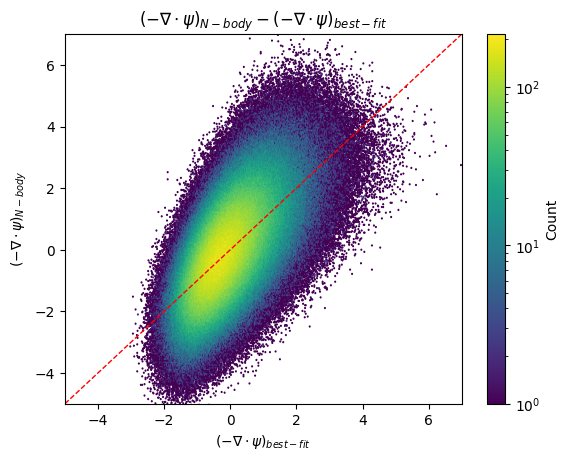

Assigning displacements to particles using CIC...
Assigning displacements to particles using CIC...


/global/u1/l/liuyh15/WorkSpace/DDDF/dddf.py:365: RuntimeWarning: invalid value encountered in sqrt
  3 * ((1 - 2 * self.growth_factor_D * delta1 / 3) ** 0.5 - 1),


Assigning displacements to particles using CIC...
best-fit χ^2=1.2028166805854699
ZA χ^2=1.1107176647898998
ALPT(rs=6) χ^2=1.1706054169732685
plotting recovered


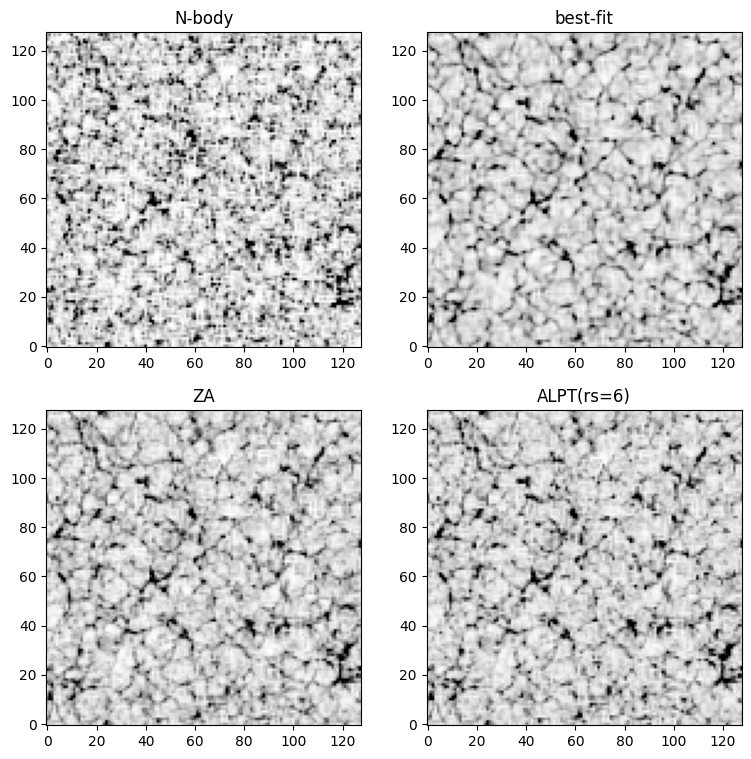

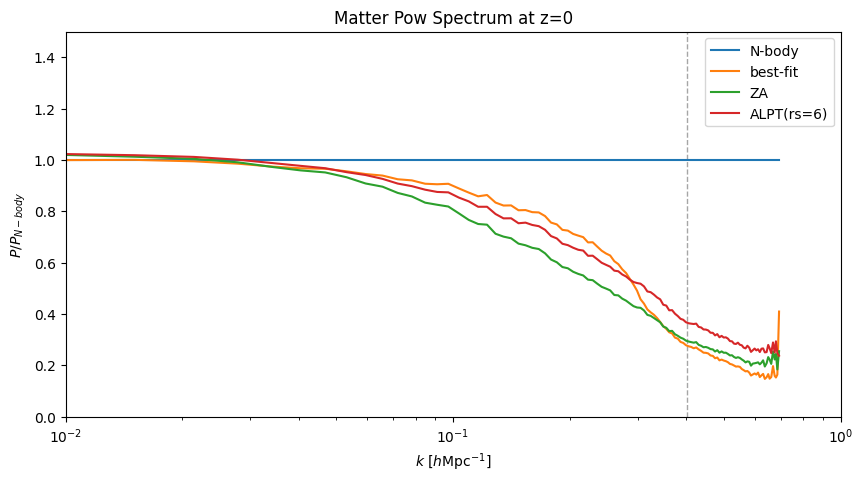

Done.


In [4]:
from tqdm.auto import tqdm

best_fit_psi_div = np.zeros_like(target_psi_div)

"""
# # fit in configuration space by cutting fields
# psi_div_layers = []
# best_fit_layers = []
# for layer in range(fit_layer):
#     print(f'Computing layer {layer}...')
#     psi_div_dict = {}
#     best_fit_coef = []
#     if layer == 0:
#         psi_div_layers.append(psi_div_1)  # ZA
#         best_fit_layers.append(psi_div_1)
#     else:
#         subsize = int(N_p / 2 ** layer) + 2 * padding
#         subboxsize = boxsize * subsize / N_p
#         # mask will be used in add_funcs
#         layer_veck = dl.Veck(subsize, subboxsize, padding=padding)
#         for i, j, k in itertools.product(range(2 ** layer), repeat=3):
#             print(i, j, k)
#             current_target_psi_div = target_psi_div.copy()
#             for best_fit in best_fit_layers:
#                 current_target_psi_div -= best_fit
#             current_psi_div_list = [
#                 dl.cut_field(current_target_psi_div, (i, j, k), layer, padding=0)]  # true value withou padding
#             sub_delta = dl.cut_field(init_delta, (i, j, k), layer, padding)
#             current_psi_div_list += dl.add_funcs(sub_delta, layer_veck)
#             current_best_fit_coef = dl.solve_best_fit(current_psi_div_list)
#             psi_div_dict[(i, j, k)] = current_psi_div_list[1:]
#             best_fit_coef.append(current_best_fit_coef)
#         avg_best_fit_coef = np.mean(best_fit_coef, axis=0)
#         avg_best_fit_field = dl.stack_layer(
#             avg_best_fit_coef, psi_div_dict, layer)
#         best_fit_layers.append(avg_best_fit_field)
#     best_fit_psi_div += best_fit_layers[layer]
"""

# fit by scale filters in x-space (not fit the last layer, no subsampling, not handle the first filter)
for layer, k_filter in enumerate(k_filters):
    if layer == len(k_filters) - 1: # not fit the last layer
        break
    print(f'fitting layer {layer}')
    current_mask = k_filter.copy()
    filtered_psi_div_list = []
    for psi_div in psi_div_list:
        if layer == len(k_filters) - 1:
            filtered_psi_div_list.append(dl.kx2x_convolve(
                current_mask, psi_div) - dl.kx2x_convolve(np.ones_like(psi_div), psi_div) + psi_div)
        else:
            filtered_psi_div_list.append(dl.kx2x_convolve(
                current_mask, psi_div))
    current_target = target_psi_div - best_fit_psi_div
    filtered_psi_div_list[0] = dl.kx2x_convolve(
                current_mask, current_target)
    layer_best_fit_coef = dl.solve_best_fit(filtered_psi_div_list)
    print(layer_best_fit_coef)
    current_best_fit = np.einsum('l,lijk->ijk',
                                 layer_best_fit_coef, filtered_psi_div_list[1:])
    print(np.mean(current_best_fit - filtered_psi_div_list[0]) ** 2)
    best_fit_psi_div += current_best_fit

'''
# fit by scale filters in x-space (not fit the last layer, no subsampling, handling the first filter)
for layer, k_filter in enumerate(k_filters):
    if layer == len(k_filters) - 1: # not fit the last layer
        break
    print(f'fitting layer {layer}')
    current_mask = k_filter.copy()
    filtered_psi_div_list = []
    if not layer==0:
        for psi_div in psi_div_list:
            if layer == len(k_filters) - 1:
                filtered_psi_div_list.append(dl.kx2x_convolve(
                    current_mask, psi_div) - dl.kx2x_convolve(np.ones_like(psi_div), psi_div) + psi_div)
            else:
                filtered_psi_div_list.append(dl.kx2x_convolve(
                    current_mask, psi_div))
        current_target = target_psi_div - best_fit_psi_div
        filtered_psi_div_list[0] = dl.kx2x_convolve(
                    current_mask, current_target)
    else:
        best_fit_psi_div += dl.kx2x_convolve(
                    current_mask, psi_div_list[1])
        continue
        filtered_psi_div_list.append(dl.kx2x_convolve(
                    current_mask, psi_div_list[0]))
        filtered_psi_div_list.append(dl.kx2x_convolve(
                    current_mask, psi_div_list[1]))
    layer_best_fit_coef = dl.solve_best_fit(filtered_psi_div_list)
    print(layer_best_fit_coef)
    current_best_fit = np.einsum('l,lijk->ijk',
                                 layer_best_fit_coef, filtered_psi_div_list[1:])
    print(np.mean(current_best_fit - filtered_psi_div_list[0]) ** 2)
    best_fit_psi_div += current_best_fit
'''

'''
# fit by scale filters in x-space (not fit the last layer, subsampling)
for layer, k_filter in enumerate(k_filters):
    if layer == len(k_filters) - 1:  # not fit the last layer
        break
    print(f"fitting layer {layer}")
    current_mask = k_filter.copy()
    for pre_filter in k_filters[:layer]:
        current_mask *= 1 - pre_filter
    filtered_psi_div_list = []
    if layer != 0:
        for i, psi_div in enumerate(psi_div_list):
            if i == 0:
                psi_div = (psi_div_list[0] - best_fit_psi_div).copy() # fit diff~~!!!!?????????
            if layer == len(k_filters) - 1:
                filtered_psi_div_list.append(
                    dl.kx2x_convolve(current_mask, psi_div)
                    - dl.kx2x_convolve(np.ones_like(psi_div), psi_div)
                    + psi_div
                )
            else:
                filtered_psi_div_list.append(dl.kx2x_convolve(current_mask, psi_div))
    else:
        filtered_psi_div_list = [
            dl.kx2x_convolve(current_mask, target_psi_div),
            dl.kx2x_convolve(current_mask, psi_div_1),
        ]

    # subsampling
    if layer == 0:
        subsample_mask = np.ones_like(target_psi_div, dtype=bool)
        layer_best_fit_coef = dl.solve_best_fit(filtered_psi_div_list, subsample_mask)
        print(layer_best_fit_coef)
        current_best_fit = np.einsum(
            "l,lijk->ijk", layer_best_fit_coef, filtered_psi_div_list[1:]
        )
    elif layer == 1:
        subsamp_times = 10
        subsamp_layer_best_fit_coefs = []
        subsample_mask = np.zeros_like(target_psi_div, dtype=bool)
        for n in tqdm(range(subsamp_times)):
            subsample_mask = rng.choice(2, subsample_mask.shape, p=[0.2, 0.8])
            current_layer_best_fit_coef = dl.solve_best_fit(
                filtered_psi_div_list, subsample_mask
            )
            subsamp_layer_best_fit_coefs.append(current_layer_best_fit_coef)
        mean_layer_best_fit_coef = np.mean(subsamp_layer_best_fit_coefs, axis=0)
        std_layer_best_fit_coef = np.std(subsamp_layer_best_fit_coefs, axis=0)
        print(mean_layer_best_fit_coef)
        print(std_layer_best_fit_coef)
        print(f"{std_layer_best_fit_coef / mean_layer_best_fit_coef}")
        fig = figure(figsize=(10, 5))
        ax = fig.add_subplot(111)
        ax.errorbar(
            np.arange(len(mean_layer_best_fit_coef)),
            mean_layer_best_fit_coef,
            std_layer_best_fit_coef,
        )
        plt.show()
        current_best_fit = np.einsum(
            "l,lijk->ijk", mean_layer_best_fit_coef, filtered_psi_div_list[1:]
        )

    print(np.mean(current_best_fit - filtered_psi_div_list[0]) ** 2)
    best_fit_psi_div += current_best_fit
'''

# # fit by scale filters in k-space
# configs = [(0, 0.4), (0.4, 0.4), (0.8, 0.4)]
# psi_div_list = [target_psi_div]
# psi_div_list += dl.add_funcs(init_delta, veck_main)
# for layer, (k0, r0) in enumerate(configs):
#     print(f'fitting layer {layer}')
#     current_mask = dl.k_tophat_filter(k0, r0, veck_main)
#     for pre_k0, pre_r0 in configs[:layer]:
#         current_mask *= 1 - dl.k_tophat_filter(pre_k0, pre_r0, veck_main)
#     k_filtered_psi_div_list = []
#     for psi_div in psi_div_list:
#         if layer == len(configs) - 1:
#             k_filtered_psi_div_list.append(dl.kx2k_convolve(
#                 current_mask, psi_div) - dl.kx2k_convolve(np.ones_like(psi_div), psi_div) + psi_div)
#         else:
#             k_filtered_psi_div_list.append(dl.kx2k_convolve(
#                 current_mask, psi_div))
#     layer_best_fit_coef = dl.k_solve_best_fit(k_filtered_psi_div_list)
#     k_current_best_fit = np.einsum('l,lijk->ijk',
#                                    layer_best_fit_coef, k_filtered_psi_div_list[1:])
#     print(np.mean(np.abs(k_current_best_fit.real - k_filtered_psi_div_list[0].real) ** 2))
#     best_fit_psi_div += pyfftw.builders.ifftn(k_current_best_fit)().real


drawfigs(best_fit_psi_div)
print("Done.")

Assigning displacements to particles using CIC...
Assigning displacements to particles using CIC...


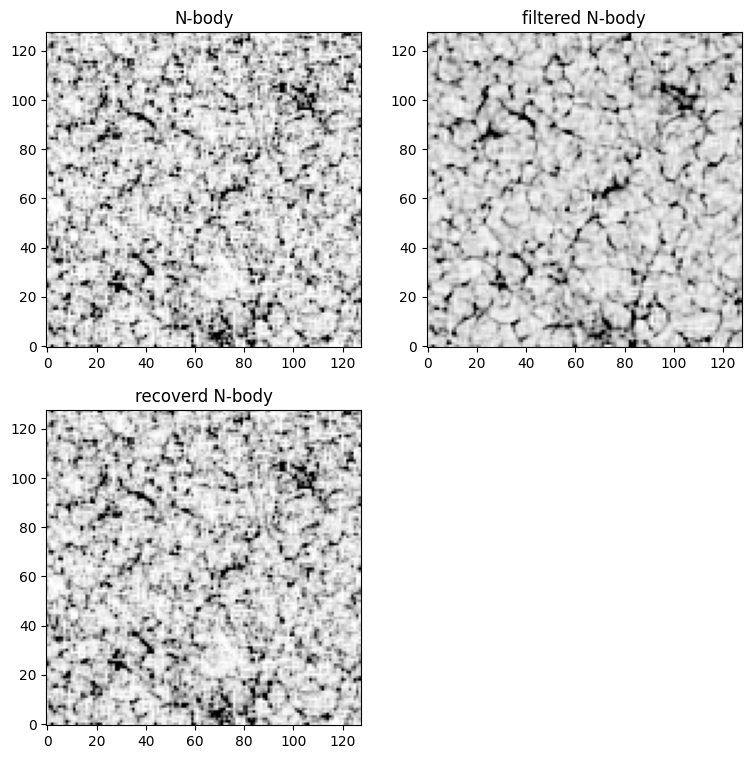

plotting recovered


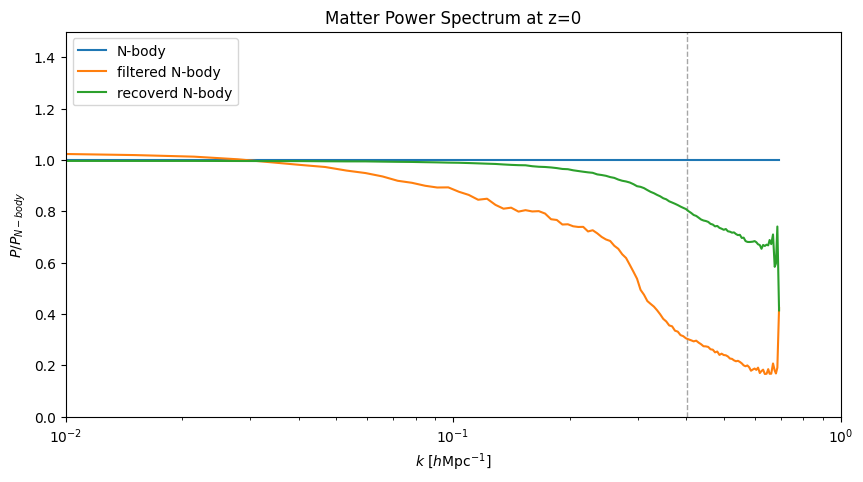

In [5]:
labels = ['N-body', 'filtered N-body', 'recoverd N-body']
final_pos = [snapshot_info[1]['pos'],
             dl.par_pos_from_psi_div(np.sum([dl.kx2x_convolve(k_filter, dl.div_ALPT(dl.disp_from_psi_div(
        psi_div_1 + psi_div_2, veck_main, veck_main.mask.shape[0]),veck_main, 6,init_delta)) for k_filter in k_filters[:-1]], axis=0),
                                     snapshot_info[0]['pos'], veck_main, N_p, boxsize),
             dl.par_pos_from_psi_div(target_psi_div,
                                     snapshot_info[0]['pos'], veck_main, N_p, boxsize)
             ]
    # snapshot_info[0]['pos'], veck_main, N_p, boxsize),
overdensities = []

fig = figure(figsize=(9, 9))
for i in range(len(final_pos)):
    delta = np.zeros(
        (grid_size, grid_size, grid_size), dtype=dl.real_dtype)
    current_pos = final_pos[i]
    # construct 3D density field
    MASL.MA(current_pos,
            delta, boxsize, 'CIC', verbose=False)

    delta = delta / np.mean(delta) - 1

    mean_overdensity = np.mean(
        delta[:, :, :1], axis=2)  # compress to 2D

    ax = fig.add_subplot(221 + i)
    ax.imshow(mean_overdensity.T, cmap='gray_r', vmin=-1.0,
              vmax=3, origin='lower')
    ax.set_title(labels[i])
    overdensities.append(delta)

plt.show()

# compute bispectrum 
Pks = [  # compute matter power spectrum
    PKL.Pk(
        overdensities[n],
        boxsize,
        axis=0,
        MAS=MAS,
        threads=8,
        verbose=False,
    )
    for n in range(len(overdensities))
]

# k1 = 0.2    #h/Mpc
# k2 = 0.2    #h/Mpc
# theta = np.linspace(0, np.pi, 25) #array with the angles between k1 and k2

# Bks = [
#     PKL.Bk(
#         overdensities[n],
#         boxsize,
#         k1,
#         k2,
#         theta,
#         MAS=MAS,
#         threads=8,
#     )
#     for n in range(len(overdensities))
# ]

# fig = figure(figsize=(10, 5))
# ax = fig.add_subplot(111)
# ax.set_xscale('linear')
# ax.set_xlabel(r'$\theta$')
# ax.set_ylabel(r'$Bk/Bk_{N-body}$')
# ax.set_xlim(0.0, np.pi)
# ax.set_ylim(0.0, 1.5)
# ax.set_title(f'Matter Bispectrum at z=0, k1={k1}, k2={k2}')

# for n in range(len(overdensities)):
#     ax.plot(
#         theta,
#         [
#             (Bks[n].B[i])
#             / (Bks[0].B[i])
#             for i in range(len(theta))
#         ],
#         label=labels[n]
#     )
# plt.legend()

# plt.show()

fig = figure(figsize=(10, 5))
ax = fig.add_subplot(111)
ax.set_xscale('log')
ax.set_xlabel(r'$k~[h{\rm Mpc}^{-1}]$')
ax.set_ylabel(r'$P/P_{N-body}$')
ax.set_xlim(0.01, 1.0)
ax.set_ylim(0.0, 1.5)
ax.set_title('Matter Power Spectrum at z=0')
ax.axvline(x=veck_main.Nyquist_freq, color='grey', linestyle='--', linewidth=1, alpha=0.7)

print('plotting recovered')

for n in range(len(overdensities)):
    ax.plot(
        Pks[0].k3D,
        [
            (Pks[n].Pk[i, 0])
            / (Pks[0].Pk[i, 0])
            for i in range(len(Pks[0].k3D))
        ],
        label=labels[n]
    )
plt.legend()

plt.show()